<a href="https://colab.research.google.com/github/rohanraaj2/Spoken-and-Natural-Language-Understanding/blob/main/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignmnet 1 (100 points)

**Name:** Rohan Raj <br>
**Email:** ror0011@thi.de <br>
**Group:** A <br>
**Hours spend *(optional)* :** <br>

General Rules:

- No helping libraries allowed.
- The use of standard libraries provided by the programming language itself (e.g., built-in data structures like lists and dictionaries, basic input/output functions, core mathematical functions) is generally permitted. These are considered fundamental to the language and not "helping libraries" in the context of this regulation
- If you need to use special Python modules, you can discuss with your instructor before submission.
- You can use the provided libraries but not mndatary.
- Always try To bulid your code from scratch.


### Question 1: Zipf’s law *(20 points)*

<p>Verify Zipf’s law on a textual corpus. The jungle book dataset is provided in the "Datasets and Resources" file. (You can also use any other dataset of your choice). <p>

<p> Provide a list of unique word sorted by their frequency in descending order. Also, give a brief discussion of the findings. You can use matplotlib library to plot the linear curve, and a log-log curve.</p>



[('the', 3732), ('and', 2355), ('of', 1348), ('to', 1290), ('a', 1173), ('he', 1097), ('in', 747), ('that', 683), ('his', 659), ('i', 658), ('was', 536), ('for', 467), ('is', 466), ('said', 442), ('with', 436), ('as', 427), ('it', 411), ('s', 404), ('they', 387), ('on', 379), ('him', 373), ('all', 356), ('you', 354), ('but', 342), ('at', 320), ('not', 310), ('had', 290), ('up', 281), ('or', 247), ('little', 241), ('have', 240), ('mowgli', 228), ('when', 214), ('out', 211), ('be', 207), ('by', 203), ('we', 203), ('there', 200), ('are', 197), ('one', 196), ('down', 193), ('my', 190), ('then', 180), ('man', 180), ('will', 180), ('were', 172), ('from', 171), ('this', 170), ('would', 166), ('me', 163), ('no', 152), ('what', 152), ('jungle', 150), ('their', 148), ('if', 148), ('them', 144), ('who', 142), ('into', 140), ('very', 140), ('head', 139), ('so', 136), ('do', 133), ('bagheera', 131), ('could', 127), ('back', 123), ('go', 121), ('rikki', 119), ('can', 119), ('nag', 116), ('never', 11

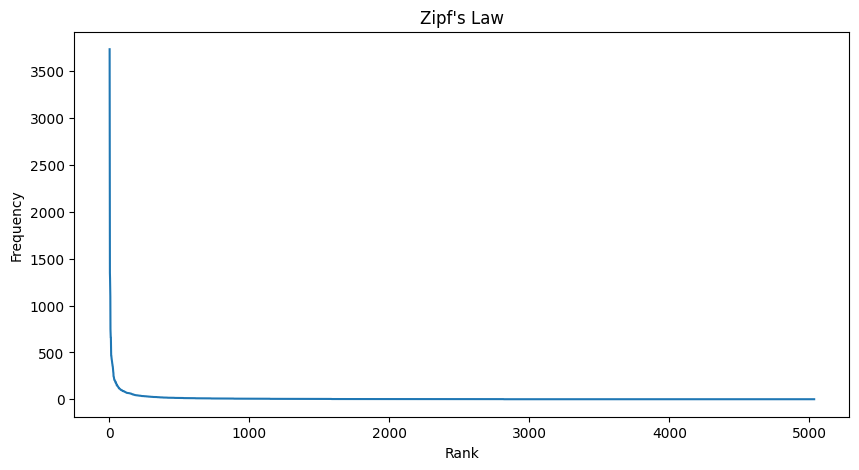

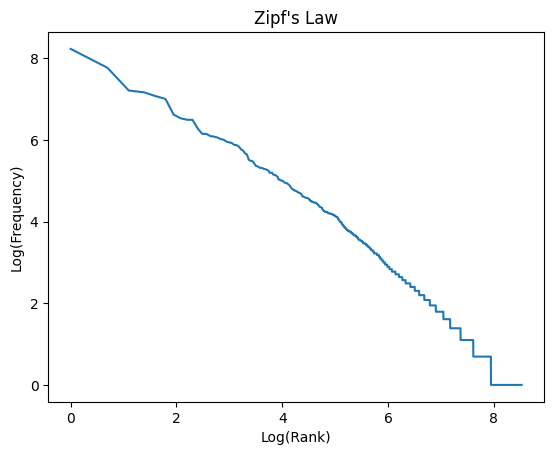


The plot shows that it indeed follows Zipf's Law


In [ ]:
### You migh use these libraries if needed.

import matplotlib.pyplot as plt
import string
import math

###### TO DO ##########
# AI was used only in the data preprocessing, sorting of dictionary and syntax for plotting.
with open("Datasets and resources/jungle_book.txt", "r") as file:
    text = file.read() # Reading the file. It basically takes the content of the file and stores it in the text variable as string.
    lowercasetext = text.lower()
    cleanedtext = ""
    cleanedtextlist = []
    for char in lowercasetext:
        if char.isalpha() or char.isspace():
            cleanedtextlist.append(char) # anything that is not an alphabet or space is ignored
        else:
            cleanedtextlist.append(" ") # This is done to cater to punctuation
    cleanedtext = "".join(cleanedtextlist)
    tokenized = cleanedtext.split() # each word is split into 'tokens'

word_dict = {} # We create a dictionary to store unique words as keys and their instances as their values
for word in tokenized:
    if word not in word_dict:
        word_dict[word] = 1
    else:
        word_dict[word] += 1
sorted_dict = sorted(word_dict.items(), key=lambda item: item[1], reverse=True) # We sorted the dictionary by descending order of frequency of the words/tokens in a list format
print (sorted_dict)
print ("The dictionary shows that the commonly used words are used the most")

plt.figure(figsize=(10, 5))

rank_list = [] # We create a list of ranks to use as input for plotting the graph
log_rank_list = []
for index in range(len(sorted_dict)):
    rank_list.append(index + 1)
    log_rank_list.append(math.log(index + 1)) # We take the log to check for the straight line

frequency_list = [] # We create a list of frequencies to use as input for plotting the graph
log_frequency_list = []
for values in sorted_dict:
    frequency_list.append(int(values[1]))
    log_frequency_list.append(math.log(int(values[1]))) # We take the log to check for the straight line

plt.plot(rank_list, frequency_list)
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Zipf's Law")

plt.show()

plt.plot(log_rank_list, log_frequency_list)
plt.xlabel("Log(Rank)")
plt.ylabel("Log(Frequency)")
plt.title("Zipf's Law")

plt.show()

print ("\nThere is inverse correlation between Rank and frequency. The plot shows that most words have very low frequency, near zero and only few have extremely high frequency, resulting in a steep decline after first few ranks. This seems in line with Zipf's law as the frequency across the next words decrease in multiples, hence decreasing quickly. The log plot is almost linear, showing that it indeed follows Zipf's Law.")

### Question 2: Mutual Information *(30 points)*

<p>Pointwise mutual information quantifies the statistical dependence between events ${x_{t} = w_{1} }$ and ${ x_{t+1} = w_{2}}$. ${C(w)}$ is the absolute frequency and ${N}$ is the size of the corpus. If the probability of the next word in the corpus (${w_{2}}$) is affected by the probability of the previous word (${w_{1}}$), then ${pmi(w_{1},w_{2}) = 0}$; else the pmi value is either positive or negative. </p>

$$ pmi(w_{1},w_{2}) = log \frac{P(x_{t} = w_{1}, x_{t+1} = w_{2})} {P(x_{t} = w_{1}) . P(x_{t+1} = w_{2})} \approx log \frac {C(w_{1}w_{2}) . N} {C(w_{1}) . C(w_{2})}  $$

<p>Calculate the Pointwise mutual information (PMI) for all successive word pairs (w1, w2) in the jungle book corpus. Words (not word pairs) that occur in the corpus less than 10 times should be ignored. List the 30 word pairs with the highest pmi value and the 30 word pairs with the lowest pmi value. Document your observations and discuss the validity of the independence assumption for unigram models. </p>



In [ ]:
### You migh use these libraries if needed.

import string
import math
from collections import Counter

###### TO DO #########
pmi_dict = {} # We create a dictionary to store the pmi values for each eligible word pairs
pairs_frequency = {} # We create a dictionary to store how many times two words appear together
for index in range(len(tokenized) - 1): # We take all words in the corpus into account
  current_word = tokenized[index]
  next_word = tokenized[index + 1]
  if word_dict[current_word] >= 10 and word_dict[next_word] >= 10: # We only proceed if both words appear atleast 10 times
        if (current_word, next_word) not in pairs_frequency:
            pairs_frequency[(current_word, next_word)] = 1 # If the pair is not already in dictionary, we create a new key with a value 1 since it did appear together for the first time
        else:
          pairs_frequency[(current_word, next_word)] += 1 # If the pair is already in the dictionary, we increase the count by 1
"""

AI suggested more efficient methods like:

1) I had created a nested loop above that takes one word, then runs the loop over all words that come after it. That caused error in pairs frequency and was also taking a long time. AI suggested me to just do as we run through the first and only loop.

2) It suggested to populate pmi dictionary separately (after the loop above) while I was populating in the else condition.

3) It helped with some silly mistakes like brackets, using old variables, etc:

"""

for pair in pairs_frequency: # Now we iterate through the pairs frequency dictionary to calculate pmi values for each pair
  w1, w2 = pair # we unpack the tuple into each variable
  pmi = math.log((pairs_frequency[pair] * len(tokenized)) / (word_dict[w1] * word_dict[w2]))
  pmi_dict[(w1, w2)] = pmi # After calculating the pmi value for a particular pair, we store it as value in the dictionary with the key consisting that pair

sorted_dict_descending = sorted(pmi_dict.items(), key=lambda item: item[1], reverse=True) # We sorted the dictionary by descending order of pmi values

print ("30 word pairs with the highest pmi value:")
for i in range(30):
    print (sorted_dict_descending[i])

print ("\n-----------------------------------\n")
print ("30 word pairs with the lowest pmi value:")
sorted_dict_ascending = sorted(pmi_dict.items(), key=lambda item: item[1]) # We sorted the dictionary by descending order of frequency of pmi values
for i in range(30):
    print (sorted_dict_ascending[i])

print ("The results show that the words that are used most commonly have low/negative pmi values whereas unique words have higher pmi values. I think the probability of a word appearing is affected by the previous word. Some words only come after a certain word. Unigram is a useful baseline but misses local dependencies ")

30 word pairs with the highest pmi value:
(('machua', 'appa'), 8.546469517754629)
(('united', 'states'), 8.30530746093774)
(('literary', 'archive'), 8.236314589450789)
(('cold', 'lairs'), 7.697318088718102)
(('archive', 'foundation'), 7.582388122044125)
(('paragraph', 'f'), 7.534868606076149)
(('bandar', 'log'), 7.418004265936838)
(('petersen', 'sahib'), 7.389016729063585)
(('stretched', 'myself'), 7.342496713428693)
(('hind', 'legs'), 7.237785759339662)
(('fore', 'paws'), 7.160175156634739)
(('hind', 'flippers'), 7.13770230078268)
(('tree', 'tops'), 7.032341785124854)
(('troop', 'horse'), 7.031166006035842)
(('bath', 'room'), 7.00602447680748)
(('twenty', 'yoke'), 6.988324899708079)
(('paragraph', 'e'), 6.977853599840784)
(('electronic', 'works'), 6.955380743988725)
(('master', 'words'), 6.9190130998178505)
(('whole', 'line'), 6.907178642170847)
(('years', 'ago'), 6.890842222851154)
(('within', 'days'), 6.875338036315188)
(('bring', 'news'), 6.872493084182957)
(('bat', 'bat'), 6.84172

### Question 3: Wikipedia language model *(50 points)*

<p> A customer of yours is dissatisfied with the quality of the speech recognition. After a conversation with the customer, you find out that he dictates books. The initial investigations on a book excerpt have shown that the language model used is not suitable. For building a better language model for the application, you have asked your customer to provide a text from the book (see "Datasets and Resources") </p>

<p> In order to save costs and also to avoid problems with copyrights, your company has decided not to use existing solutions for this project. So, you have to implement a 2-gram language model in Python from scratch. Include a short description of the data preprocessing steps, method, experiment design, hyper-parameters, and evaluation metric. Also, document your findings, drawbacks, and potential improvements.</p>



<h4> Datasets and Resources </h4>

* WikiText-2 (raw/unprocessed), Train, Dev, Test

In [24]:
######## You might use these libraries if needed.

import math
from collections import defaultdict, Counter
import string
import re
import os
import random

####### TO DO #######
"""
The following description was generated by AI. However, I wrote a bit myself before, which was "The way to approach this problem would be preprocess data such as cleaning the data by taking into account the upper, lower case letters, errors, punctuation. Then, the text will be split into words/tokens using split() method. Once that's done. We will run a loop over all tokens and count how many times a word came before the next word. Then calculate the probability by taking that value and dividing it by the total times the next word being used in the corpus. We will evaluate by using the dev dataset. Once it's evaluated. We will run the model on test dataset."

1. Data Preprocessing:
   - Clean text: Convert to lowercase and handle punctuation.
   - Tokenization: Split text into individual words/tokens.
   - Vocabulary Building: Replace rare words (occurring < 5 times) with an <UNK> token.
   - Sentence Markers: Add <s> and </s> tags to mark boundaries for bigram modeling.

2. Method:
   - Implement a 2-gram (Bigram) language model from scratch.
   - I will iterate through the sentence bounded list and as we iterate, I append the two word pairs in the dictionary as key and update the value of the keys if the key is already there in dictionary. Once we have the dictionary. Then we will calculate the probability of two words appearing together by dividng the number of times they appeared together by number of times the previous word appeared
   - Calculate P(w_n | w_{n-1}) = C(w_{n-1}, w_n) / C(w_{n-1}).
   - Use log-probabilities to avoid numerical underflow during long sequence calculations.

3. Experiment Design:
   - Training: Use the WikiText-2 Train set to compute frequencies.
   - Validation: Use the Dev set to tune any smoothing parameters or handling of <UNK>.
   - Testing: Evaluate the final model performance on the Test set.

4. Hyper-parameters:
   - Smoothing: Apply Laplace (Add-1 or Add-k) smoothing to handle zero-count bigrams.
   - Unknown threshold: Define the frequency count to categorize words as <UNK>.

5. Evaluation Metric:
   - Perplexity (PP): The primary metric to evaluate how well the model predicts the test data. Lower perplexity indicates better performance.
"""

# I decided to clean data using cleanedtext += char. However, it was slow and AI suggested me to use list instead.

log_probabilities = {}
word_counts_training = Counter()
word_counts_training_with_tags = Counter()
pair_frequency_training = Counter()
laplace_constant = 0.01
back_off_implement = True

def bigram(filename):
  global word_counts_training, word_counts_training_with_tags, pair_frequency_training, laplace_constant
  with open("Datasets and resources/wikitext-2-raw-v1/wikitext-2-raw/wiki." + filename + ".raw", "r") as file:
    text = file.read() # Reading the file. It basically takes the content of the file and stores it in the text variable as string.
    lowercasetext = text.lower()
    processed_tokens = []

    tokens = re.findall(r"\w+|[.!\?]", lowercasetext)

    if filename == 'train':
      word_counts_training = Counter(tokens)
      for word in tokens:
        if word_counts_training[word] >= 5:
          processed_tokens.append(word)
        else:
          processed_tokens.append('<UNK>')

    elif filename == 'valid' or filename == 'test':
      for word in tokens:
        if word not in word_counts_training:
          processed_tokens.append('<UNK>') # Even if the word appears more than 5 times in valid/test dataset, it will be converted and assigned probability of <UNK> in the train dataset.
        else:
          processed_tokens.append(word)

    # I was inserting sentence boundaries within the same list processed_tokens. But AI suggested to create a new list.
    sentence_bounded_list = []
    sentence_bounded_list.append('<s>')
    for i in range (len(processed_tokens)):
      sentence_bounded_list.append(processed_tokens[i])
      if processed_tokens[i] in {'.', '!', '?'} and i != len(processed_tokens) - 1:
        sentence_bounded_list.append('</s>')
        sentence_bounded_list.append('<s>')
    sentence_bounded_list.append('</s>')

    if filename == 'train':
      word_counts_training_with_tags = Counter(sentence_bounded_list)
      pair_list = []
    else:
      total_log_probability = 0
      bigram_count = 0
    for i in range(len(sentence_bounded_list) - 1):
      current_word = sentence_bounded_list[i]
      next_word = sentence_bounded_list[i + 1]
      if current_word != '</s>' and next_word != '<s>':
        pair = (current_word, next_word)
        if filename == 'valid' or filename == 'test':
          bigram_count += 1
          if pair in pair_frequency_training:
            smoothed_probability = ((pair_frequency_training[pair] + laplace_constant) / (word_counts_training_with_tags[pair[0]] + (laplace_constant * len(word_counts_training_with_tags))))
          else:
            if (back_off_implement):
              smoothed_probability = back_off(word_counts_training_with_tags, next_word)
            else:
              smoothed_probability = laplace_constant / (word_counts_training_with_tags[pair[0]] + (laplace_constant * len(word_counts_training_with_tags))) # Here we probability of the two words appearing together as zero.
          total_log_probability += math.log(smoothed_probability)
        elif filename == 'train':
          pair_list.append(pair)

    if filename == 'train':
      pair_frequency_training = Counter(pair_list)
    else:
      perplexity = math.exp(-total_log_probability / bigram_count)
      if (back_off_implement):
        print("Perplexity for the", filename, "dataset with back off implementation is", perplexity)
      else:
        print("Perplexity for the", filename, "dataset with laplace smoothing is", perplexity)

bigram('train')
bigram('valid')
bigram('test')

print ("Findings: Perplexity is affected by laplace constant value. If it's too high, it over smoothes and gives too much mass to unseen bigrams and as a result, perplexity increases, whereas if it's too low, it under smoothes and gives unseen bigrams near-zero probability, making perplexity high.")
print ("Drawbacks: Some data is lost such as those that are converted to <UNK> and bigram context is short, only limited to two consecutive words and cannot capture long-range dependencies.")
print ("Improvements: Laplace constant should be optimized. While it can be done by trial and error as done in this code by trying different values manually and checking the perplexity, a mathematical method could be used to find the most optimal value. The drawbacks of that would be more computations will be required. Another improvement could be to improve tokenization and normalization.")

Perplexity for the valid dataset with back off implementation is 270.3205399910438
Perplexity for the test dataset with back off implementation is 255.79308530065882
Findings: Perplexity is affected by laplace constant value. If it's too high, it over smoothes and gives too much mass to unseen bigrams and as a result, perplexity increases, whereas if it's too low, it under smoothes and gives unseen bigrams near-zero probability, making perplexity high.
Drawbacks: Some data is lost such as those that are converted to <UNK> and bigram context is short, only limited to two consecutive words and cannot capture long-range dependencies.
Improvements: Laplace constant should be optimized. While it can be done by trial and error as done in this code by trying different values manually and checking the perplexity, a mathematical method could be used to find the most optimal value. The drawbacks of that would be more computations will be required. Another improvement could be to improve tokeniza

### Additional Experiments *(5 additional points - <span style="color: red;">Optional</span>)*


- Calculate Bigram Probabilities with Back-off.
- Demonstrate and discuss your Back-off implementation.


In [23]:
def back_off(word_counts_training_with_tags, next_word):
  if next_word not in word_counts_training_with_tags:
    next_word = '<UNK>'
  probability = word_counts_training_with_tags[next_word] / sum(word_counts_training_with_tags.values())
  return probability

print ("The Back-off implementation is done such that if the bigram pair does not exist in the train dataset, we use the general probability of the next word appearing in the whole corpus.")
print ("The model has a lower perplexity when unseen pairs are dealt by back off implementation. Hence, it performs better. This is because the probability is more realistic and consistent unlike laplace smoothing where there was a uniform probability given to all unseen pairs.")

The Back-off implementation is done such that if the bigram pair does not exist in the train dataset, we use the general probability of the next word appearing in the whole corpus.
